<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Setup" data-toc-modified-id="Setup-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Setup</a></span><ul class="toc-item"><li><span><a href="#Check-your-sample-table-(i.e.-metadata-file)" data-toc-modified-id="Check-your-sample-table-(i.e.-metadata-file)-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Check your sample table (i.e. metadata file)</a></span></li><li><span><a href="#Check-your-TRN" data-toc-modified-id="Check-your-TRN-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Check your TRN</a></span></li><li><span><a href="#Load-the-data" data-toc-modified-id="Load-the-data-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Load the data</a></span></li></ul></li><li><span><a href="#Regulatory-iModulons" data-toc-modified-id="Regulatory-iModulons-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Regulatory iModulons</a></span></li><li><span><a href="#Functional-iModulons" data-toc-modified-id="Functional-iModulons-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Functional iModulons</a></span><ul class="toc-item"><li><span><a href="#GO-Enrichments" data-toc-modified-id="GO-Enrichments-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>GO Enrichments</a></span></li><li><span><a href="#KEGG-Enrichments" data-toc-modified-id="KEGG-Enrichments-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>KEGG Enrichments</a></span><ul class="toc-item"><li><span><a href="#Load-KEGG-mapping" data-toc-modified-id="Load-KEGG-mapping-3.2.1"><span class="toc-item-num">3.2.1&nbsp;&nbsp;</span>Load KEGG mapping</a></span></li><li><span><a href="#Perform-enrichment" data-toc-modified-id="Perform-enrichment-3.2.2"><span class="toc-item-num">3.2.2&nbsp;&nbsp;</span>Perform enrichment</a></span></li><li><span><a href="#Convert-KEGG-IDs-to-human-readable-names" data-toc-modified-id="Convert-KEGG-IDs-to-human-readable-names-3.2.3"><span class="toc-item-num">3.2.3&nbsp;&nbsp;</span>Convert KEGG IDs to human-readable names</a></span></li></ul></li><li><span><a href="#SubtiWiki-categories" data-toc-modified-id="SubtiWiki-categories-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>SubtiWiki categories</a></span></li><li><span><a href="#Save-files" data-toc-modified-id="Save-files-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Save files</a></span></li></ul></li><li><span><a href="#Check-for-single-gene-iModulons" data-toc-modified-id="Check-for-single-gene-iModulons-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Check for single gene iModulons</a></span></li><li><span><a href="#Save-iModulon-object" data-toc-modified-id="Save-iModulon-object-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Save iModulon object</a></span></li></ul></div>

# Setup
This IPython notebook will walk through the steps of characterizing iModulons through the semi-automated tools in PyModulon. You will need:

* M and A matrices
* Expression data (e.g. `log_tpm_norm.csv`)
* Gene table and KEGG/GO annotations (Generated in `1_create_the_gene_table.ipynb`)
* Sample table, with a column for `project` and `condition`
* TRN file

Optional:
* iModulon table (if you already have some characterized iModulons)

In [1]:
from pymodulon.core import IcaData
from pymodulon.plotting import *
from os import path
import pandas as pd
import re
from Bio.KEGG import REST
from tqdm.notebook import tqdm

## Check your sample table (i.e. metadata file)
Your metadata file will probably have a lot of columns, most of which you may not care about. Feel free to save a secondary copy of your metadata file with only columns that seem relevant to you. The two most important columns are:
1. `project`
2. `condition`

Make sure that these columns exist in your metadata file

In [2]:
df_metadata = pd.read_csv('C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\sample_table_final.csv',index_col=0)
df_metadata[['project','condition']].head()

,project,condition
pmg_wt_1,CFP,WT
pmg_wt_2,CFP,WT
pmg_wt_3,INDIMOD,M9_glucose
pmg_wt_4,INDIMOD,M9_glucose
pmg_wt_5,INDIMOD,sorbital_arginine


In [3]:
print(df_metadata.project.notnull().all())
print(df_metadata.condition.notnull().all())

True
True


## Check your TRN

Each row of the TRN file represents a regulatory interaction.  
**Your TRN file must have the following columns:**
1. `regulator` - Name of regulator (`/` or `+` characters will be converted to `;`)
1. `gene_id` - Locus tag of gene being regulated

The following columns are optional, but are helpful to have:
1. `regulator_id` - Locus tag of regulator
1. `gene_name` - Name of gene (can automatically update this using `name2num`)
1. `direction` - Direction of regulation ('+' for activation, '-' for repression, '?' or NaN for unknown)
1. `evidence` - Evidence of regulation (e.g. ChIP-exo, qRT-PCR, SELEX, Motif search)
1. `PMID` - Reference for regulation

You may add any other columns that could help you. TRNs may be saved as either CSV or TSV files. See below for an example:

In [4]:
df_trn = pd.read_csv('C:\\Users\\99hee\\precise_mg1655_R1\\data\\regulation\\TRN_updated.csv')
df_trn.head()

,regulator,gene_name,gene_id,effect,evidence,source
0,Lrp,alaE,b2670,-+,2.0,RegulonDB_TF
1,MqsA,mqsR,b3022,-,2.0,RegulonDB_TF
2,NarP,nirB,b3365,+,2.0,RegulonDB_TF
3,ArcA,nuoK,b2279,-,2.0,RegulonDB_TF
4,NarP,cysG,b3368,+,2.0,RegulonDB_TF


The `regulator` and `gene_id` must be filled in for each row

In [5]:
print(df_trn.regulator.notnull().all())
print(df_trn.gene_id.notnull().all())

True
True


## Load the data
You're now ready to load your IcaData object!

In [64]:
ica_data = IcaData(M = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\M.csv',
                   A = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\A.csv',
                   X = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\log_tpm_final.csv',
                   gene_table = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\annotation\\gene_info.csv',
                   sample_table = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\p_mg1655\\sample_table_final.csv',
                   trn = 'C:\\Users\\99hee\\precise_mg1655_R1\\data\\regulation\\TRN_updated.csv',
                   optimize_cutoff=True)

## Checking if any iModulon is empty
Manually set the threshold for empty iModulons

In [65]:
for idx in ica_data.imodulon_table.index.values:
    if ica_data.view_imodulon(idx).shape[0] == 0:
        print(idx)

67
70
106
107
109


In [8]:
from pymodulon.plotting import *

C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\plotting.py:836: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  mod_cogs = ica_data.gene_table.loc[component_genes].COG


<AxesSubplot: xlabel='Gene Start', ylabel='109 Gene Weight'>

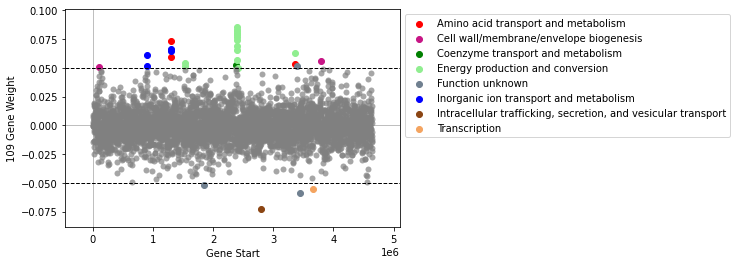

In [95]:
plot_gene_weights(ica_data, 109)

In [94]:
# ica_data.change_threshold(67, 0.06)
# ica_data.change_threshold(70, 0.05)
# ica_data.change_threshold(106, 0.07)
# ica_data.change_threshold(107, 0.07)
# ica_data.change_threshold(109, 0.05)

In [97]:
ica_data.view_imodulon(109)

,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,regulator
b0086,0.050661,murF,U00096.3,NaN,94650,96008,+,D-alanyl-D-alanine-adding enzyme,Cell wall/membrane/envelope biogenesis,P11880,Op86,"MraZ,PdhR,RpoD,LexA"
b0861,0.051524,artM,U00096.3,NaN,900866,901534,-,L-arginine ABC transporter membrane subunit ArtM,Inorganic ion transport and metabolism,P0AE30,Op833,"ArgR,ppGpp,RpoS,RpoD"
b0862,0.060815,artQ,U00096.3,NaN,901534,902250,-,L-arginine ABC transporter membrane subunit ArtQ,Inorganic ion transport and metabolism,P0AE34,Op834,"ArgR,ppGpp,RpoS,RpoD"
b1244,0.059794,oppB,U00096.3,NaN,1302899,1303819,+,murein tripeptide ABC transporter/oligopeptide...,Amino acid transport and metabolism,P0AFH2,Op1216,"Lrp,Fur,FliA,ArcA,gcvB,ModE,Spermidine"
b1245,0.073623,oppC,U00096.3,NaN,1303834,1304742,+,murein tripeptide ABC transporter/oligopeptide...,Amino acid transport and metabolism,P0AFH6,Op1217,"Lrp,Fur,Nac,FliA,ArcA,gcvB,ModE,Spermidine"
b1246,0.065010,oppD,U00096.3,NaN,1304754,1305767,+,murein tripeptide ABC transporter/oligopeptide...,Inorganic ion transport and metabolism,P76027,Op1218,"Lrp,Fur,FliA,ArcA,gcvB,ModE,Spermidine"
b1247,0.066076,oppF,U00096.3,NaN,1305764,1306768,+,murein tripeptide ABC transporter/oligopeptide...,Inorganic ion transport and metabolism,P77737,Op1219,"Lrp,Fur,FliA,ArcA,gcvB,ModE,Spermidine"
b1467,0.054195,narY,U00096.3,NaN,1537309,1538853,-,nitrate reductase Z subunit beta,Energy production and conversion,P19318,Op1448,OmpR
b1468,0.051990,narZ,U00096.3,NaN,1538850,1542590,-,nitrate reductase Z subunit alpha,Energy production and conversion,P19319,Op1449,"OmpR,ppGpp,SrsR"
b1760,-0.051719,ynjH,U00096.3,NaN,1841863,1842135,-,DUF1496 domain-containing protein YnjH,Function unknown,P76227,Op1747,"GlaR,Nac,FliA,Lrp"


C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\plotting.py:836: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  mod_cogs = ica_data.gene_table.loc[component_genes].COG


<AxesSubplot: xlabel='Gene Start', ylabel='109 Gene Weight'>

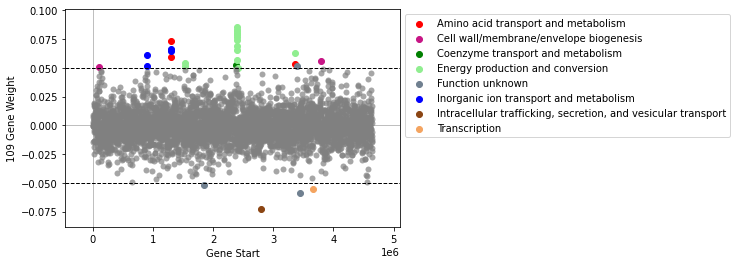

In [98]:
plot_gene_weights(ica_data, 109)

In [99]:
# ica_data.view_imodulon(107)

# Regulatory iModulons
Use `compute_trn_enrichment` to automatically check for Regulatory iModulons. The more complete your TRN, the more regulatory iModulons you'll find.

In [100]:
ica_data.compute_trn_enrichment()

,imodulon,regulator,pvalue,qvalue,precision,recall,f1score,TP,regulon_size,imodulon_size,n_regs
0,0,NagC,3.512538e-20,5.971314e-19,0.909091,0.232558,0.370370,10.0,43.0,11.0,1.0
1,2,ArcA,1.768553e-14,5.836224e-13,0.652174,0.065217,0.118577,15.0,230.0,23.0,1.0
2,4,Fnr,7.081576e-15,3.328341e-13,0.588235,0.062893,0.113636,20.0,318.0,34.0,1.0
3,4,NarL,1.105565e-13,2.598077e-12,0.411765,0.112903,0.177215,14.0,124.0,34.0,1.0
4,4,NarP,9.026319e-08,1.414123e-06,0.205882,0.137255,0.164706,7.0,51.0,34.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
248,109,IHF,8.522765e-09,7.329578e-08,0.413793,0.052632,0.093385,12.0,228.0,29.0,1.0
249,109,Spermidine,8.270881e-09,7.329578e-08,0.137931,0.800000,0.235294,4.0,5.0,29.0,1.0
250,109,Fis,6.615202e-08,4.740895e-07,0.344828,0.059524,0.101523,10.0,168.0,29.0,1.0
251,109,Fnr,3.551802e-07,2.181821e-06,0.413793,0.037736,0.069164,12.0,318.0,29.0,1.0


You can also search for AND/OR combinations of regulators using the `max_regs` argument.

Regulator enrichments can be directly saved to the `imodulon_table` using the `save` argument. This saves the enrichment with the lowest q-value to the table.

For this automated step, use strict cutoff for evidence required (can loosen later during manual annotation)

In [101]:
# First search for regulator enrichments with 2 regulators
ica_data.compute_trn_enrichment(max_regs=2, evidence=[1, 2], method = 'and', save=True)

# regulator enrichment will be checked again in detail in the next notebook

C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pymodulon\core.py:610: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  keep_cols = self.imodulon_table.loc[


,imodulon,regulator,pvalue,qvalue,precision,recall,f1score,TP,regulon_size,imodulon_size,n_regs
0,0,NagC,1.145723e-17,4.100427e-13,0.727273,0.380952,0.500000,8.0,21.0,11.0,1.0
1,0,NagC+RpoD,1.096820e-14,1.962705e-10,0.545455,0.600000,0.571429,6.0,10.0,11.0,2.0
2,0,Crp+NagC,1.620640e-10,1.933369e-06,0.454545,0.312500,0.370370,5.0,16.0,11.0,2.0
3,2,ArcA,9.945329e-18,3.560627e-13,0.652174,0.106383,0.182927,15.0,141.0,23.0,1.0
4,2,ArcA+RpoD,6.974700e-12,1.248541e-07,0.434783,0.113636,0.180180,10.0,88.0,23.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
600,109,Fis+RpoD,3.658691e-11,8.187464e-08,0.344828,0.126582,0.185185,10.0,79.0,29.0,2.0
601,109,Fnr,5.059441e-11,1.065608e-07,0.413793,0.081633,0.136364,12.0,147.0,29.0,1.0
602,109,IHF,1.603064e-10,3.188762e-07,0.413793,0.074074,0.125654,12.0,162.0,29.0,1.0
603,109,Fis,5.431182e-10,1.023492e-06,0.344828,0.097087,0.151515,10.0,103.0,29.0,1.0


The list of regulatory iModulons are shown below

In [102]:
regulatory_imodulons = ica_data.imodulon_table[ica_data.imodulon_table.regulator.notnull()]
print(len(ica_data.imodulon_table),'Total iModulons')
print(len(regulatory_imodulons),'Regulatory iModulons')
regulatory_imodulons

118 Total iModulons
62 Regulatory iModulons


,regulator,pvalue,qvalue,precision,recall,f1score,TP,regulon_size,imodulon_size,n_regs
0,NagC,1.145723e-17,4.100427e-13,0.727273,0.380952,0.500000,8.0,21.0,11.0,1.0
2,ArcA,9.945329e-18,3.560627e-13,0.652174,0.106383,0.182927,15.0,141.0,23.0,1.0
4,Fnr,1.168149e-21,4.182907e-17,0.588235,0.136054,0.220994,20.0,147.0,34.0,1.0
5,Fur,1.758530e-55,6.295360e-51,0.906977,0.268966,0.414894,39.0,145.0,43.0,1.0
6,FhlA,1.505286e-20,2.693107e-16,1.000000,0.444444,0.615385,8.0,18.0,8.0,1.0
...,...,...,...,...,...,...,...,...,...,...
99,SrsR,2.583562e-11,9.247600e-07,0.600000,0.181818,0.279070,6.0,33.0,10.0,1.0
100,CpxR,2.711929e-17,9.707077e-13,0.388889,0.212121,0.274510,14.0,66.0,36.0,1.0
102,UxuR,9.753979e-13,1.745426e-08,0.357143,0.833333,0.500000,5.0,6.0,14.0,1.0
103,MetJ,1.985701e-19,7.106428e-15,0.500000,0.800000,0.615385,8.0,10.0,16.0,1.0


You can rename iModulons in this jupyter notebook, or you can save the iModulon table as a CSV and edit it in Excel.

If two iModulons have the same regulator (e.g. 'Reg'), they will be named 'Reg-1' and 'Reg-2'

In [103]:
ica_data.rename_imodulons(regulatory_imodulons.regulator.to_dict())
ica_data.imodulon_table.head()

,regulator,pvalue,qvalue,precision,recall,f1score,TP,regulon_size,imodulon_size,n_regs
NagC,NagC,1.145723e-17,4.100427e-13,0.727273,0.380952,0.500000,8.0,21.0,11.0,1.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ArcA-1,ArcA,9.945329e-18,3.560627e-13,0.652174,0.106383,0.182927,15.0,141.0,23.0,1.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fnr-1,Fnr,1.168149e-21,4.182907e-17,0.588235,0.136054,0.220994,20.0,147.0,34.0,1.0


In [104]:
regulatory_imodulons = ica_data.imodulon_table[ica_data.imodulon_table.regulator.notnull()]

# Functional iModulons

GO annotations and KEGG pathways/modules were generated in the 1_create_the_gene_table.ipynb notebook. Enrichments will be calculated in this notebook, and further curated in the 3_manual_iModulon_curation notebook.

## GO Enrichments

First load the Gene Ontology annotations

In [105]:
DF_GO = pd.read_csv('C:\\Users\\99hee\\precise_mg1655_R1\\data\\external\\GO_annotations_curated.csv',index_col=0)
DF_GO.head()

,gene_id,gene_name,gene_ontology
0,b1304,pspA,phage shock
1,b1304,pspA,response to heat
2,b1304,pspA,cytoplasmic side of plasma membrane
3,b1304,pspA,protein binding
4,b1304,pspA,protein binding


In [106]:
DF_GO_enrich = ica_data.compute_annotation_enrichment(DF_GO,'gene_ontology')

In [107]:
DF_GO_enrich.head()

,imodulon,gene_ontology,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size
0,NagC,UDP-N-acetylglucosamine biosynthetic process,4.959893e-08,2.062323e-04,0.272727,0.750000,0.400000,3.0,7.0,11.0
1,NagC,N-acetylglucosamine catabolic process,3.552111e-05,7.384839e-02,0.181818,0.500000,0.266667,2.0,11.0,11.0
2,NagC,N-acetylglucosamine metabolic process,5.911930e-05,8.193935e-02,0.181818,0.400000,0.250000,2.0,5.0,11.0
3,1,response to cold,8.298522e-13,3.450525e-09,0.500000,0.375000,0.428571,6.0,23.0,12.0
4,1,regulation of gene expression,2.466548e-07,5.127953e-04,0.333333,0.181818,0.235294,4.0,23.0,12.0


## KEGG Enrichments

### Load KEGG mapping
The `kegg_mapping.csv` file contains KEGG orthologies, pathways, modules, and reactions. Only pathways and modules are relevant to iModulon characterization.

In [108]:
DF_KEGG = pd.read_csv('C:\\Users\\99hee\\precise_mg1655_R1\\data\external\\kegg_mapping.csv',index_col=0)
print(DF_KEGG.database.unique())
DF_KEGG.head()

['KEGG_pathway' 'KEGG_module' 'KEGG_reaction']


,gene_id,database,kegg_id
9,b0002,KEGG_pathway,map00260
10,b0002,KEGG_pathway,map00261
11,b0002,KEGG_pathway,map00270
12,b0002,KEGG_pathway,map00300
13,b0002,KEGG_pathway,map01100


In [109]:
kegg_pathways = DF_KEGG[DF_KEGG.database == 'KEGG_pathway']
kegg_modules = DF_KEGG[DF_KEGG.database == 'KEGG_module']

### Perform enrichment
Uses the `compute_annotation_enrichment` function

In [110]:
DF_pathway_enrich = ica_data.compute_annotation_enrichment(kegg_pathways,'kegg_id')
DF_module_enrich = ica_data.compute_annotation_enrichment(kegg_modules,'kegg_id')

In [111]:
DF_pathway_enrich.head()

,imodulon,kegg_id,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size
0,NagC,map00520,9.245419e-08,0.000021,0.454545,0.096154,0.158730,5.0,52.0,11.0
1,ArcA-1,map00071,2.277330e-06,0.000515,0.173913,0.210526,0.190476,4.0,19.0,23.0
2,ArcA-1,map00281,7.334275e-06,0.000646,0.130435,0.375000,0.193548,3.0,8.0,23.0
3,ArcA-1,map01212,8.568643e-06,0.000646,0.173913,0.153846,0.163265,4.0,26.0,23.0
4,ArcA-1,map00190,6.061573e-05,0.002283,0.173913,0.095238,0.123077,4.0,42.0,23.0


In [112]:
DF_module_enrich.head()

,imodulon,kegg_id,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size
0,ArcA-1,M00087,7.669989e-08,0.000026,0.173913,0.444444,0.250000,4.0,9.0,23.0
1,ArcA-1,M00149,5.312465e-07,0.000091,0.130435,0.750000,0.222222,3.0,4.0,23.0
2,ArcA-1,M00113,8.166032e-05,0.009309,0.086957,0.666667,0.153846,2.0,3.0,23.0
3,ArcA-1,M00011,1.221279e-04,0.010442,0.130435,0.157895,0.142857,3.0,19.0,23.0
4,ArcA-1,M00173,1.664606e-04,0.011386,0.130435,0.142857,0.136364,3.0,21.0,23.0


### Convert KEGG IDs to human-readable names

In [113]:
for idx,key in tqdm(DF_pathway_enrich.kegg_id.items(),total=len(DF_pathway_enrich)):
    if '-' not in key:
        text = REST.kegg_find('pathway',key).read()
    try:
        name = re.search('\t(.*)\n',text).group(1)
        DF_pathway_enrich.loc[idx,'pathway_name'] = name
    except AttributeError:
        DF_pathway_enrich.loc[idx,'pathway_name'] = None
    
for idx,key in tqdm(DF_module_enrich.kegg_id.items(),total=len(DF_module_enrich)):
    if '-' not in key:
        text = REST.kegg_find('module',key).read()
    try:
        name = re.search('\t(.*)\n',text).group(1)
        DF_module_enrich.loc[idx,'module_name'] = name
    except AttributeError:
        DF_module_enrich.loc[idx,'module_name'] = None

  0%|          | 0/234 [00:00<?, ?it/s]

  0%|          | 0/146 [00:00<?, ?it/s]

In [114]:
DF_pathway_enrich.head()

,imodulon,kegg_id,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size,pathway_name
0,NagC,map00520,9.245419e-08,0.000021,0.454545,0.096154,0.158730,5.0,52.0,11.0,Amino sugar and nucleotide sugar metabolism
1,ArcA-1,map00071,2.277330e-06,0.000515,0.173913,0.210526,0.190476,4.0,19.0,23.0,Fatty acid degradation
2,ArcA-1,map00281,7.334275e-06,0.000646,0.130435,0.375000,0.193548,3.0,8.0,23.0,None
3,ArcA-1,map01212,8.568643e-06,0.000646,0.173913,0.153846,0.163265,4.0,26.0,23.0,Fatty acid metabolism
4,ArcA-1,map00190,6.061573e-05,0.002283,0.173913,0.095238,0.123077,4.0,42.0,23.0,Oxidative phosphorylation


In [115]:
DF_module_enrich.head()

,imodulon,kegg_id,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size,module_name
0,ArcA-1,M00087,7.669989e-08,0.000026,0.173913,0.444444,0.250000,4.0,9.0,23.0,beta-Oxidation
1,ArcA-1,M00149,5.312465e-07,0.000091,0.130435,0.750000,0.222222,3.0,4.0,23.0,"Succinate dehydrogenase, prokaryotes"
2,ArcA-1,M00113,8.166032e-05,0.009309,0.086957,0.666667,0.153846,2.0,3.0,23.0,Jasmonic acid biosynthesis
3,ArcA-1,M00011,1.221279e-04,0.010442,0.130435,0.157895,0.142857,3.0,19.0,23.0,"Citrate cycle, second carbon oxidation, 2-oxog..."
4,ArcA-1,M00173,1.664606e-04,0.011386,0.130435,0.142857,0.136364,3.0,21.0,23.0,Reductive citrate cycle (Arnon-Buchanan cycle)


## Save files

In [116]:
DF_GO_enrich['source'] = 'GO'
DF_pathway_enrich['source'] = 'KEGG pathways'
DF_module_enrich['source'] = 'KEGG modules'

DF_GO_enrich.rename({'gene_ontology':'annotation'},axis=1, inplace=True)
DF_pathway_enrich.rename({'kegg_id':'annotation'},axis=1, inplace=True)
DF_module_enrich.rename({'kegg_id':'annotation'},axis=1, inplace=True)

DF_enrichments = pd.concat([DF_GO_enrich, DF_pathway_enrich, DF_module_enrich])

# Check for single gene iModulons

Some iModulons are dominated by a single, high-coefficient gene. These iModulons may result from:
1. Overdecomposition of the dataset to identify noisy genes
1. Artificial knock-out of single genes
1. Regulons with only one target gene

No matter what causes these iModulons, it is important to be aware of them. The find_single_gene_imodulons function identifies iModulons that are likely dominated by a single gene.

The iModulons identified by ``find_single_gene_imodulons`` may contain more than one gene, since a threshold-agnostic method is used to identify these iModulons.

In [117]:
sg_imods = ica_data.find_single_gene_imodulons(save=True)
len(sg_imods)

24

In [118]:
for i,mod in enumerate(sg_imods):
    ica_data.rename_imodulons({mod:'SG_'+str(i+1)})

In [119]:
ica_data.imodulon_table[ica_data.imodulon_table.single_gene == True]

,regulator,pvalue,qvalue,precision,recall,f1score,TP,regulon_size,imodulon_size,n_regs,single_gene
SG_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
SG_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
SG_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
SG_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
SG_5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
SG_6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
SG_7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
SG_8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
SG_9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
SG_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


# Save iModulon object

In [123]:
from pymodulon.util import explained_variance
from pymodulon.io import *

In [124]:
# Add iModulon sizes and explained variance
for im in ica_data.imodulon_names:
    ica_data.imodulon_table.loc[im,'imodulon_size'] = len(ica_data.view_imodulon(im))
    ica_data.imodulon_table.loc[im,'explained_variance'] = explained_variance(ica_data,imodulons=im)

This will save your iModulon table, your thresholds, and any other information stored in the ica_data object.

In [139]:
# save_to_json(ica_data, 'C:\\Users\\99hee\\precise_mg1655\\data\\p_mg1655\\PRECISE_WT_MG1655_redo.json.gz')

If you prefer to view and edit your iModulon table in excel, save it as a CSV and reload the iModulon as before

In [71]:
# ica_data.imodulon_table.to_csv('C:\\Users\\99hee\\precise_mg1655\\data\\p_mg1655\\imodulon_table_raw.csv')

C:\Users\99hee\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\internals\blocks.py:2323: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)
